In [1]:
import numpy as np
from matplotlib import pyplot as plt

from cr_knee_fit.plotting import (
    CARTO_VIVID,
)

In [2]:
alpha = 2
R0 = 1e-1
mean_R_max = 1
sigma_lgR_max = 0.5
A0 = 1.0  # arbitrary normalization
beta = 1.0


def pl(R: np.ndarray) -> np.ndarray:
    return A0 * (R / R0) ** (-alpha)


def pl_scaled(R: np.ndarray, Rmax: float) -> np.ndarray:
    return Rmax**beta * pl(R)


def single_source_heaviside(R: np.ndarray, Rmax: float, lower: bool = False) -> np.ndarray:
    mask = (R < Rmax) if not lower else (R > Rmax)
    return pl_scaled(R, Rmax) * mask


def single_source_exp(R: np.ndarray, Rmax: float) -> np.ndarray:
    return pl_scaled(R, Rmax) * np.exp(-R / Rmax)


def single_source_exp_Delta(R: np.ndarray, Rmax: float, Delta: float) -> np.ndarray:
    return pl_scaled(R, Rmax) * np.exp(-((R / Rmax) ** Delta))

In [3]:
ln10 = np.log(10)


def lognormal_dist_shape(R: np.ndarray, mu: float, sigma: float, beta: float):
    lgR = np.log10(R)
    return 0.5 * special.erfc((lgR - mu - beta * sigma**2 * ln10) / (np.sqrt(2) * sigma))


def lognormal_dist_norm_bias(mu: float, sigma: float, beta: float):
    return np.exp(mu * beta * ln10 + 0.5 * (beta * ln10 * sigma) ** 2)

In [4]:
from matplotlib.axes import Axes
from matplotlib.typing import ColorType


def _plot_erfc(
    ax: Axes,
    mu: float,
    sigma: float,
    R_grid: np.ndarray,
    with_sampling_error: bool,
    A: float = 1.0,
    line_label: str = "Limiting $\\text{erfc}$",
    line_color: ColorType = CARTO_VIVID(2),  # noqa: B008
    band_label: str
    | None = "$ \\langle \\lg \\mathcal{R}_\\text{max} \\rangle \\pm \\sigma(\\lg \\mathcal{R}_\\text{max}) $",
    band_color: ColorType = "tab:red",
):
    mean_theory = (
        A
        * lognormal_dist_norm_bias(mu, sigma, beta)
        * pl(R_grid)
        * lognormal_dist_shape(R_grid, mu, sigma, beta)
    )
    mean_sq_theory = (
        A
        * A0
        * lognormal_dist_norm_bias(mu, sigma, 2 * beta)
        * pl(R_grid) ** 2
        * lognormal_dist_shape(R_grid, mu, sigma, 2 * beta)
    )
    std_theory = np.sqrt(mean_sq_theory - mean_theory**2)
    std_mean = std_theory / np.sqrt(n_sources)

    if with_sampling_error:
        line_label += " with sampling error"

    ax.plot(
        R_grid,
        R_grid**scale * mean_theory,
        lw=2,
        ls="--",
        color=line_color,
        label=line_label,
        zorder=3,
    )
    ax.fill_between(
        R_grid,
        R_grid**scale * (mean_theory - std_mean),
        R_grid**scale * (mean_theory + std_mean),
        color=line_color,
        alpha=0.3,
        zorder=1,
    )

    if band_label is not None:
        ax.axvline(10**mu, color=band_color)
        ax.axvspan(
            10 ** (mu - sigma),
            10 ** (mu + sigma),
            color=band_color,
            alpha=0.2,
            label=band_label,
        )

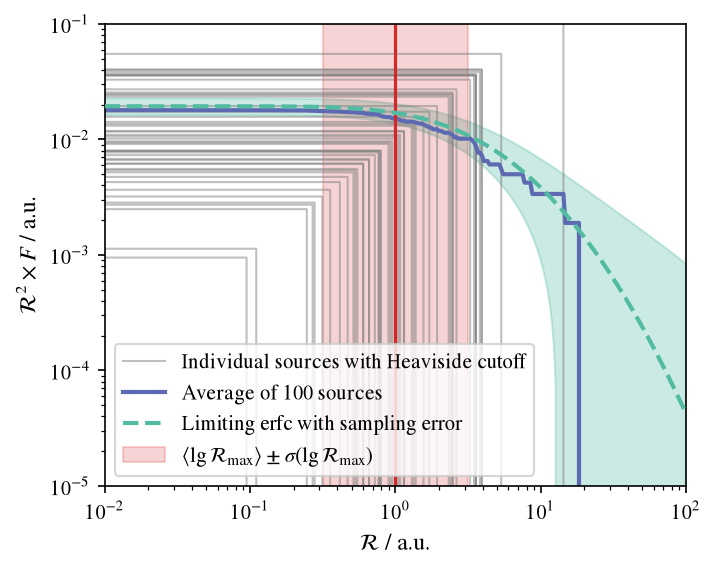

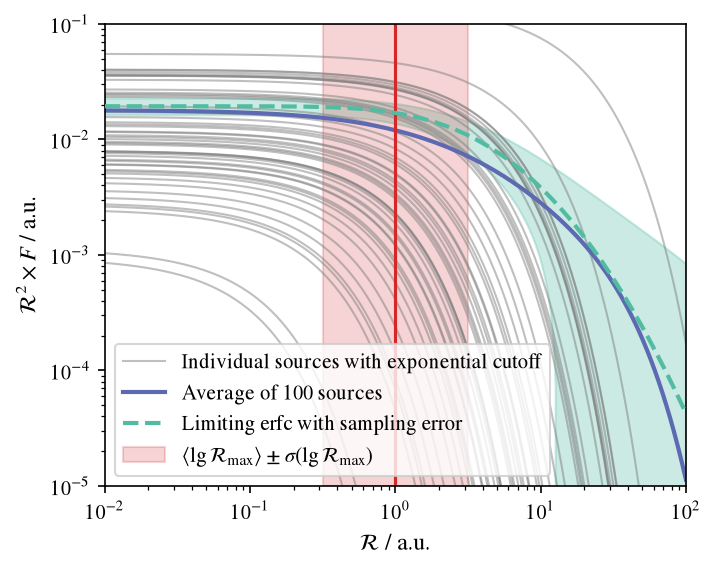

In [5]:
from scipy import special, stats

n_sources = 100
mu = np.log10(mean_R_max)
sigma = sigma_lgR_max
Rmax_sample = 10 ** stats.norm.rvs(mu, sigma, size=n_sources)

for single_source, cutoff_label, added_sigma in (
    (single_source_heaviside, "Heaviside", None),
    (single_source_exp, "exponential", None),
):
    R_grid = np.geomspace(1e-2, 1e2, 300)

    sources = []
    for Rmax in Rmax_sample:
        sources.append(single_source(R_grid, Rmax))

    fig, ax = plt.subplots(figsize=(5, 4))
    scale = 2

    for i, spec in enumerate(sources[:50]):
        ax.plot(
            R_grid,
            R_grid**scale * spec,
            lw=1,
            color="gray",
            alpha=0.5,
            label=f"Individual sources with {cutoff_label} cutoff" if i == 0 else None,
        )

    ax.plot(
        R_grid,
        R_grid**scale * np.mean(sources, axis=0),
        lw=2,
        color=CARTO_VIVID(1),
        zorder=2,
        label=f"Average of {Rmax_sample.size} sources",
    )

    if added_sigma is not None:
        sigma += added_sigma

    _plot_erfc(ax=ax, mu=mu, sigma=sigma, R_grid=R_grid, with_sampling_error=True)

    ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
    ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
    ax.set_xlim(R_grid[0], R_grid[-1])
    ax.set_ylim(1e-5, 1e-1)

# Observed $\sigma$ for finite # of sources and/or non-Heaviside cutoff


In [6]:
import iminuit


def fit_with_lognormal(
    R_grid: np.ndarray,
    target_shape: np.ndarray,
    verbose: bool,
    cutoff_depth: float = 1e-2,
) -> tuple[np.ndarray, float, float, float, float]:
    indices_past_depth = np.nonzero(target_shape / pl(R_grid) < cutoff_depth)[0]
    idx_max = indices_past_depth[0] if len(indices_past_depth) > 0 else -1
    if verbose:
        print(f"Fitting up to index {idx_max} / {len(target_shape)} (R = {R_grid[idx_max]:.2g})")

    to_fit = np.log10(target_shape[:idx_max])

    def nll(params: np.ndarray) -> float:
        A, mu, sigma = params
        approx = np.log10(
            A
            * lognormal_dist_norm_bias(mu, sigma, beta)
            * pl(R_grid)
            * lognormal_dist_shape(R_grid, mu, sigma, beta)
        )[:idx_max]
        return np.sqrt(((to_fit - approx) ** 2).mean())

    res = iminuit.minimize(
        nll,
        x0=[1.0, 0, 0.3],
        bounds=[(0, None), (None, None), (0, None)],
    )
    if verbose:
        print(res)
    A, mu, sigma = res.x
    return target_shape, A, mu, sigma, res.fun

Fitting up to index 271 / 300 (R = 42)
  message: Optimization terminated successfully.
  success: True
      fun: 0.03141818126607636
        x: [ 1.291e+00 -2.162e-01  5.133e-01]
 hess_inv: ┌────┬───────────────────┐
           │    │    x0    x1    x2 │
           ├────┼───────────────────┤
           │ x0 │  12.5  -4.8  1.08 │
           │ x1 │  -4.8  1.94 -0.45 │
           │ x2 │  1.08 -0.45 0.108 │
           └────┴───────────────────┘
     nfev: 134
     njev: 0
   minuit: ┌─────────────────────────────────────────────────────────────────────────┐
           │                                Migrad                                   │
           ├──────────────────────────────────┬──────────────────────────────────────┤
           │ FCN = 0.03142                    │              Nfcn = 134              │
           │ EDM = 2.57e-05 (Goal: 0.0001)    │                                      │
           ├──────────────────────────────────┼──────────────────────────────────────┤
   

(1e-05, 0.1)

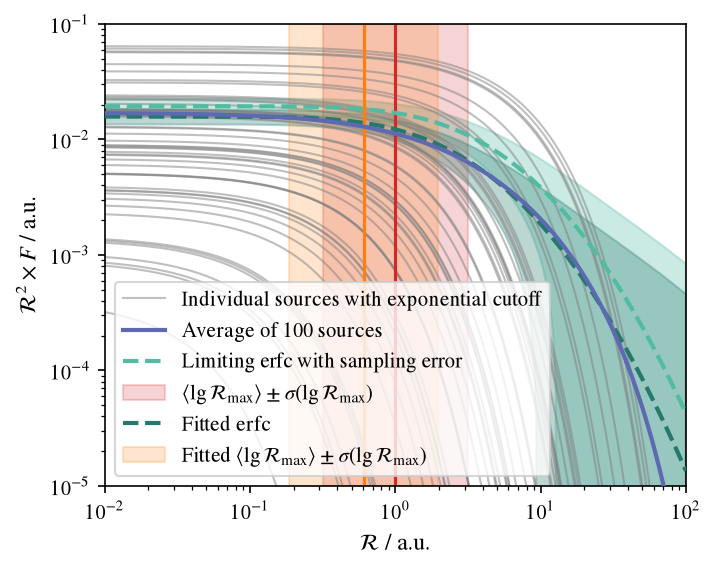

In [25]:
from scipy import stats

n_sources = 100
mu = np.log10(mean_R_max)
sigma = sigma_lgR_max
R_grid = np.geomspace(1e-2, 1e2, 300)

Rmax_sample = 10 ** stats.norm.rvs(mu, sigma, size=n_sources)

single_source = single_source_exp

sources = []
for Rmax in Rmax_sample:
    sources.append(single_source(R_grid, Rmax))
signal = np.mean(sources, axis=0)

_, A_bf, mu_bf, sigma_bf, nll = fit_with_lognormal(
    R_grid, target_shape=signal, verbose=True, cutoff_depth=1e-2
)

fig, ax = plt.subplots(figsize=(5, 4))
scale = 2

for i, spec in enumerate(sources[:50]):
    ax.plot(
        R_grid,
        R_grid**scale * spec,
        lw=1,
        color="gray",
        alpha=0.5,
        label=f"Individual sources with {cutoff_label} cutoff" if i == 0 else None,
    )

ax.plot(
    R_grid,
    R_grid**scale * signal,
    lw=2,
    color=CARTO_VIVID(1),
    zorder=100,
    label=f"Average of {Rmax_sample.size} sources",
)

_plot_erfc(ax=ax, mu=mu, sigma=sigma, R_grid=R_grid, with_sampling_error=True)
_plot_erfc(
    ax=ax,
    mu=mu_bf,
    sigma=sigma_bf,
    R_grid=R_grid,
    with_sampling_error=False,
    A=A_bf,
    line_label="Fitted erfc",
    line_color=CARTO_VIVID(5),
    band_label="Fitted $ \\langle \\lg \\mathcal{R}_\\text{max} \\rangle \\pm \\sigma(\\lg \\mathcal{R}_\\text{max}) $",
    band_color="tab:orange",
)

ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlim(R_grid[0], R_grid[-1])
ax.set_ylim(1e-5, 1e-1)

In [39]:
import itertools

from tqdm import trange

mu = np.log10(mean_R_max)
sigma = sigma_lgR_max

R_grid = np.geomspace(1e-2, 1e2, 300)
n_MC = 3000

sigma_samples: list[tuple[int, str, list[float]]] = []

for (single_source_spec, single_source_spec_name), n_sources in itertools.product(
    zip((single_source_heaviside, single_source_exp), ("Heaviside", "exponential")),
    (100, 1000, 10_000),
):
    sigma_sample = []
    for _ in trange(n_MC):
        Rmax_sample = 10 ** stats.norm.rvs(mu, sigma, size=n_sources)
        sources = []
        for Rmax in Rmax_sample:
            sources.append(single_source_spec(R_grid, Rmax))
        signal = np.mean(sources, axis=0)

        _, A_bf, mu_bf, sigma_bf, nll = fit_with_lognormal(
            R_grid,
            target_shape=signal,
            verbose=False,
            cutoff_depth=1e-2,
        )
        sigma_sample.append(sigma_bf)
    sigma_samples.append((n_sources, single_source_spec_name, sigma_sample))

 21%|██        | 623/3000 [00:07<00:33, 71.14it/s]/var/folders/pt/5p7r1p1j49n8f_88l1j7jtwc0000gn/T/ipykernel_2196/2602674147.py:10: RuntimeWarning: overflow encountered in exp
  return np.exp(mu * beta * ln10 + 0.5 * (beta * ln10 * sigma) ** 2)
/var/folders/pt/5p7r1p1j49n8f_88l1j7jtwc0000gn/T/ipykernel_2196/1168048447.py:19: RuntimeWarning: divide by zero encountered in log10
  approx = np.log10(
100%|██████████| 3000/3000 [05:22<00:00,  9.29it/s]


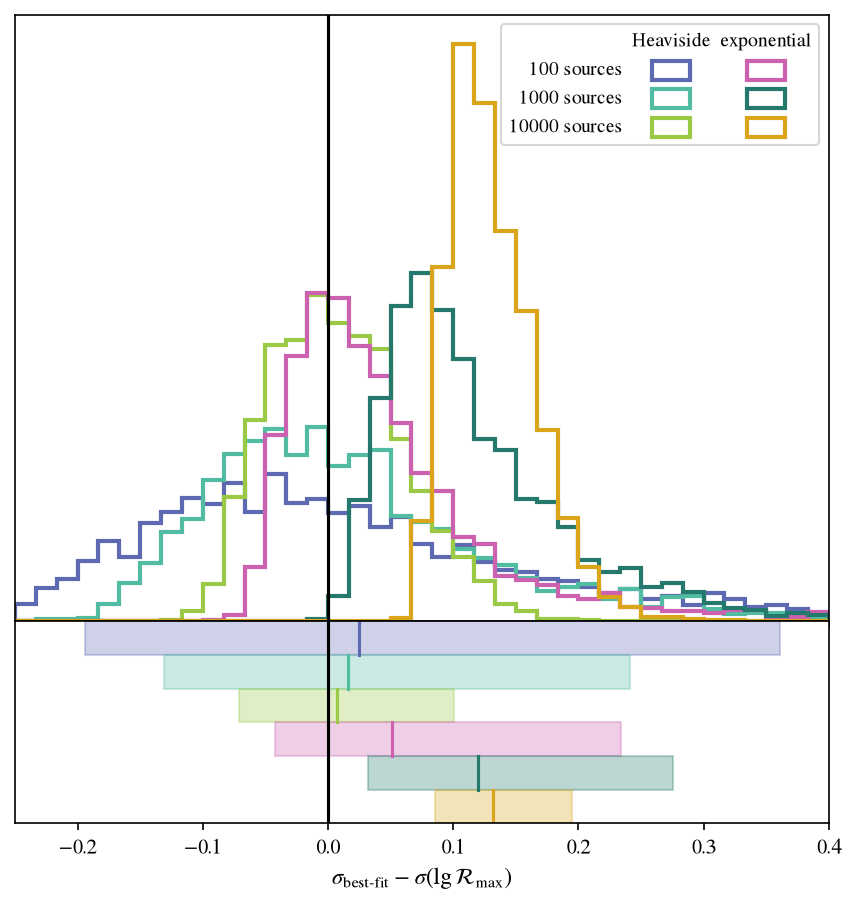

In [41]:
from collections.abc import Sequence
from matrix_legend import matrix_legend

fig, axes = plt.subplots(nrows=2, figsize=(7, 7), sharex=True, height_ratios=[3, 1])
axes: Sequence[Axes]

bins = np.linspace(-0.25, 0.4, 40)

total_cases = len(sigma_samples)
for i, (n_sources, sss, sigma_sample) in enumerate(sigma_samples):
    color = CARTO_VIVID(i + 1)
    sigma_sample = [s - sigma for s in sigma_sample]
    axes[0].hist(
        sigma_sample,
        bins=bins,
        label=f"{n_sources} sources | {sss}",
        lw=2,
        histtype="step",
        color=color,
    )
    axes[1].axvline(
        np.mean(sigma_sample), color=color, ymin=1 - i / total_cases, ymax=1 - (i + 1) / total_cases
    )
    axes[1].axvspan(
        xmin=np.quantile(sigma_sample, q=0.05),
        xmax=np.quantile(sigma_sample, q=0.95),
        color=color,
        ymin=1 - i / total_cases,
        ymax=1 - (i + 1) / total_cases,
        alpha=0.3,
    )

for ax in axes:
    ax.axvline(0.0, color="k")
    ax.set_yticks([])
axes[1].set_xlabel("$\\sigma_\\text{best-fit} - \\sigma(\\lg \\mathcal{R}_\\text{max})$")
axes[0].set_xlim(bins[0], bins[-1])
axes[0].legend()
matrix_legend(axes[0], fontsize="small")
fig.subplots_adjust(hspace=0.0)

# $\sigma(\Delta)$ corresponding to a naive $\exp(-(R/R_\text{cut})^\Delta)$ cutoff


In [28]:
R_grid = np.geomspace(1e-2, 3e1, 300)


def fit_lognormal_to_exp(
    verbose: bool, Delta: float, cutoff_depth: float = 1e-2
) -> tuple[np.ndarray, float, float, float, float]:
    target_shape = single_source_exp_Delta(R_grid, mean_R_max, Delta)
    return fit_with_lognormal(R_grid, target_shape, verbose, cutoff_depth)

Fitting up to index 230 / 300 (R = 4.7)
  message: Optimization terminated successfully.
  success: True
      fun: 0.0347437914318366
        x: [ 1.518e+00 -3.549e-01  3.430e-01]
 hess_inv: ┌────┬──────────────────────┐
           │    │     x0     x1     x2 │
           ├────┼──────────────────────┤
           │ x0 │   9.44   -2.7   0.78 │
           │ x1 │   -2.7  0.834  -0.25 │
           │ x2 │   0.78  -0.25 0.0784 │
           └────┴──────────────────────┘
     nfev: 154
     njev: 0
   minuit: ┌─────────────────────────────────────────────────────────────────────────┐
           │                                Migrad                                   │
           ├──────────────────────────────────┬──────────────────────────────────────┤
           │ FCN = 0.03474                    │              Nfcn = 154              │
           │ EDM = 1.28e-06 (Goal: 0.0001)    │                                      │
           ├──────────────────────────────────┼──────────────────────

/var/folders/pt/5p7r1p1j49n8f_88l1j7jtwc0000gn/T/ipykernel_2196/1168048447.py:19: RuntimeWarning: divide by zero encountered in log10
  approx = np.log10(


(1e-05, 0.1)

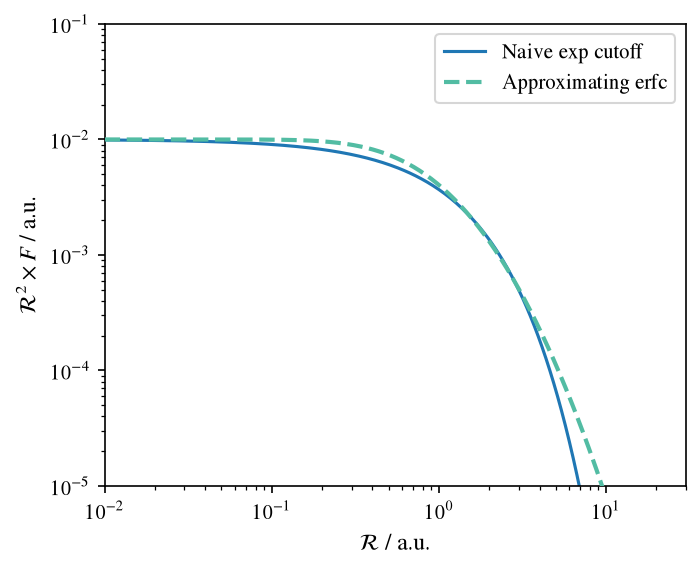

In [29]:
exp_shape, _, mu_bf, sigma_bf, _ = fit_lognormal_to_exp(verbose=True, Delta=1.0, cutoff_depth=1e-2)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(R_grid, R_grid**2 * exp_shape, label="Naive exp cutoff")

ax.plot(
    R_grid,
    R_grid**scale * pl(R_grid) * lognormal_dist_shape(R_grid, mu_bf, sigma_bf, beta),
    lw=2,
    ls="--",
    color=CARTO_VIVID(2),
    zorder=100,
    label="Approximating $\\text{erfc}$",
)

ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlim(R_grid[0], R_grid[-1])
ax.set_ylim(1e-5, 1e-1)

In [30]:
Delta_grid = np.linspace(0.5, 3, 50)

mus = []
sigmas = []
nlls = []
for Delta in Delta_grid:
    exp_shape, mu, _, sigma, nll = fit_lognormal_to_exp(verbose=False, Delta=Delta)
    mus.append(mu)
    sigmas.append(sigma)
    nlls.append(nll)

/var/folders/pt/5p7r1p1j49n8f_88l1j7jtwc0000gn/T/ipykernel_2196/1168048447.py:19: RuntimeWarning: divide by zero encountered in log10
  approx = np.log10(
/var/folders/pt/5p7r1p1j49n8f_88l1j7jtwc0000gn/T/ipykernel_2196/2602674147.py:10: RuntimeWarning: overflow encountered in exp
  return np.exp(mu * beta * ln10 + 0.5 * (beta * ln10 * sigma) ** 2)


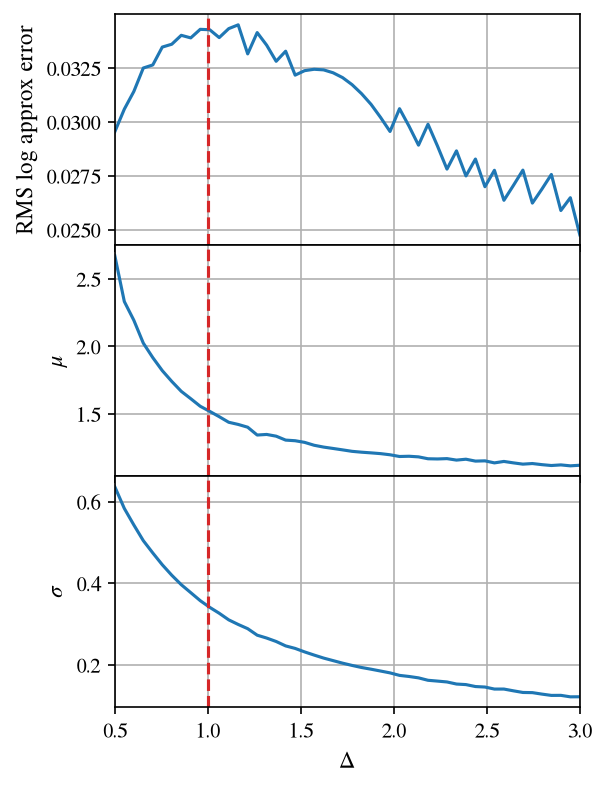

In [31]:
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(4, 6), sharex=True)

axes[0].plot(Delta_grid, nlls)
axes[0].set_ylabel("RMS log approx error")

axes[1].plot(Delta_grid, mus)
axes[1].set_ylabel("$\\mu$")

axes[2].plot(Delta_grid, sigmas)
axes[2].set_xlabel("$\\Delta$")
axes[2].set_ylabel("$\\sigma$")

axes[2].set_xlim(Delta_grid[0], Delta_grid[-1])


for ax in axes:
    ax.axvline(1.0, color="tab:red", ls="--")
    ax.grid(True, "major")

fig.subplots_adjust(hspace=0)

# Low-R population cutoff


In [32]:
ln10 = np.log(10)


def lower_lognormal_dist_shape(R: np.ndarray, mu: float, sigma: float, beta: float):
    lgR = np.log10(R)
    return 0.5 * (1 + special.erf((lgR - mu - beta * ln10 * sigma**2) / (np.sqrt(2) * sigma)))


def lower_lognormal_dist_norm_bias(mu: float, sigma: float, beta: float):
    return np.exp(mu * beta * ln10 + 0.5 * (beta * ln10 * sigma) ** 2)

(1e-05, 0.1)

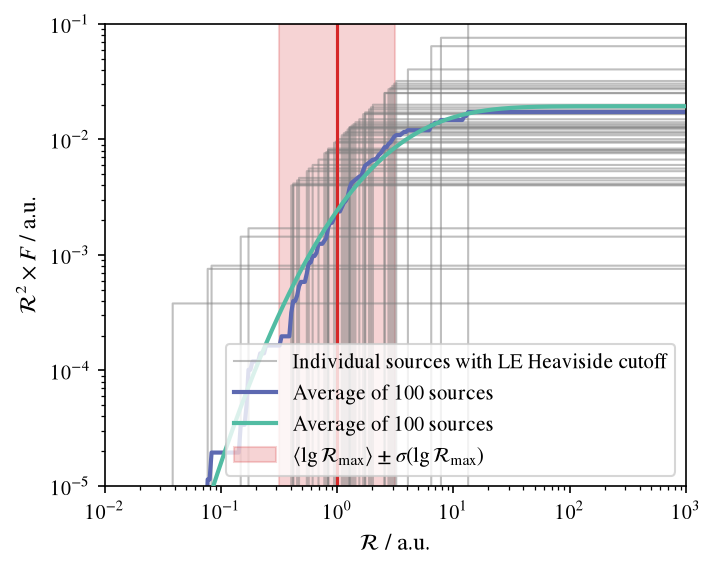

In [34]:
n_sources = 100
mu = np.log10(mean_R_max)
sigma = sigma_lgR_max
Rmax_sample = 10 ** stats.norm.rvs(mu, sigma, size=n_sources)

R_grid = np.geomspace(1e-2, 1e3, 300)

sources = []
for Rmax in Rmax_sample:
    sources.append(single_source_heaviside(R_grid, Rmax, lower=True))

fig, ax = plt.subplots(figsize=(5, 4))
scale = 2

for i, spec in enumerate(sources[:50]):
    ax.plot(
        R_grid,
        R_grid**scale * spec,
        lw=1,
        color="gray",
        alpha=0.5,
        label="Individual sources with LE Heaviside cutoff" if i == 0 else None,
    )

ax.plot(
    R_grid,
    R_grid**scale * np.mean(sources, axis=0),
    lw=2,
    color=CARTO_VIVID(1),
    zorder=2,
    label=f"Average of {Rmax_sample.size} sources",
)

ax.plot(
    R_grid,
    R_grid**scale
    * lower_lognormal_dist_norm_bias(mu, sigma, beta)
    * pl(R_grid)
    * lower_lognormal_dist_shape(R_grid, mu, sigma, beta),
    lw=2,
    color=CARTO_VIVID(2),
    zorder=3,
    label=f"Average of {Rmax_sample.size} sources",
)

ax.axvline(10**mu, color="tab:red")
ax.axvspan(
    10 ** (mu - sigma),
    10 ** (mu + sigma),
    color="tab:red",
    alpha=0.2,
    label="$ \\langle \\lg \\mathcal{R}_\\text{max} \\rangle \\pm \\sigma(\\lg \\mathcal{R}_\\text{max}) $",
)

ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlim(R_grid[0], R_grid[-1])
ax.set_ylim(1e-5, 1e-1)